In [25]:
#imports 
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.preprocessing import LabelEncoder

In [2]:
df=pd.read_csv("data_center_hybrid.csv")
print(df.index)
print("All columns are")
ai=0
for i in df:
    print(ai,i)
    ai+=1

RangeIndex(start=0, stop=126770, step=1)
All columns are
0 Year
1 Facility_ID
2 Facility_Name
3 Owner_Company
4 City
5 Country
6 Facility_Type
7 Estimated_Capacity_MW
8 PUE
9 Cooling_System_Type
10 WUE_L_per_kWh
11 Daily_Electricity_Usage_MWh
12 Daily_Water_Usage_Gallons
13 Surrounding_Water_Stress_Tier


In [3]:
df.shape

(126770, 14)

In [4]:
df.head()

,Year,Facility_ID,Facility_Name,Owner_Company,City,Country,Facility_Type,Estimated_Capacity_MW,PUE,Cooling_System_Type,WUE_L_per_kWh,Daily_Electricity_Usage_MWh,Daily_Water_Usage_Gallons,Surrounding_Water_Stress_Tier
0,2019,DC-D2763E00,NAP de las Americas Madrid,Terremark,Madrid,Spain,Enterprise/Standard,6.24,1.975,Evaporative,1.481,183.62,36362.94,Low
1,2020,DC-D2763E00,NAP de las Americas Madrid,Terremark,Madrid,Spain,Enterprise/Standard,6.36,1.967,Evaporative,1.459,254.34,49833.60,Low
2,2021,DC-D2763E00,NAP de las Americas Madrid,Terremark,Madrid,Spain,Enterprise/Standard,6.47,1.928,Evaporative,1.450,266.85,53026.35,Low
3,2022,DC-D2763E00,NAP de las Americas Madrid,Terremark,Madrid,Spain,Enterprise/Standard,6.59,1.897,Evaporative,1.413,199.14,39198.30,Low
4,2023,DC-D2763E00,NAP de las Americas Madrid,Terremark,Madrid,Spain,Enterprise/Standard,6.70,1.869,Evaporative,1.389,225.94,44366.48,Low


In [5]:
df.sample(n=10)

,Year,Facility_ID,Facility_Name,Owner_Company,City,Country,Facility_Type,Estimated_Capacity_MW,PUE,Cooling_System_Type,WUE_L_per_kWh,Daily_Electricity_Usage_MWh,Daily_Water_Usage_Gallons,Surrounding_Water_Stress_Tier
29507,2021,DC-5117716E,NorthC Winterthur (Zurich) 1,NorthC Datacenters,Winterthur,Unknown,Enterprise/Standard,11.46,1.621,Evaporative,2.545,341.93,141813.29,Medium
78704,2022,DC-3008CF56,Tustin 1 Data Center,Lumen,Unknown,United States,Enterprise/Standard,3.62,1.582,Evaporative,1.712,83.21,23799.23,High
45367,2019,DC-57539FA5,Data Canopy - Austin Waller,Data Canopy,Austin,United States,Enterprise/Standard,2.92,1.995,Evaporative,2.259,97.26,29081.92,Medium
53379,2023,DC-87AEFACF,Ardent Georgia,Ardent Data Centers,Maysville,United States,Enterprise/Standard,12.71,1.863,Evaporative,1.871,344.67,91468.80,Medium
71549,2021,DC-CEF32653,Iron Mountain VA-5,Iron Mountain,Unknown,United States,Colocation,51.20,1.595,Evaporative,1.500,1458.92,362429.27,High
81392,2022,DC-DB73C1CF,CyberNest VA,CyberNest,Unknown,United States,Enterprise/Standard,9.27,1.584,Evaporative,1.400,293.82,68617.60,Medium
16932,2025,DC-8C52D3A2,Gent,Hostbasket,Lochristi,Belgium,Enterprise/Standard,13.85,1.544,Air Cooled,0.204,356.03,12402.98,Medium
50560,2025,DC-3A7921E8,H5 Data Centers Virginia,H5 Data Centers,Chantilly,United States,Enterprise/Standard,4.75,1.629,Air Cooled,0.198,134.93,4335.55,Low
48881,2019,DC-68508F55,ATI DC-2,ATI Solutions Inc.,Tysons,United States,Enterprise/Standard,14.94,1.876,Air Cooled,0.194,617.28,16877.73,Medium
110881,2020,DC-3E3C4F01,Amsterdam AMS3 Data Center,Digital Realty,Unknown,Netherlands,Colocation,80.20,1.456,Evaporative,1.916,1722.52,598812.86,Medium


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 126770 entries, 0 to 126769
Data columns (total 14 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   Year                           126770 non-null  int64  
 1   Facility_ID                    126770 non-null  object 
 2   Facility_Name                  126770 non-null  object 
 3   Owner_Company                  126770 non-null  object 
 4   City                           126770 non-null  object 
 5   Country                        126770 non-null  object 
 6   Facility_Type                  126770 non-null  object 
 7   Estimated_Capacity_MW          126770 non-null  float64
 8   PUE                            126770 non-null  float64
 9   Cooling_System_Type            126770 non-null  object 
 10  WUE_L_per_kWh                  126770 non-null  float64
 11  Daily_Electricity_Usage_MWh    126770 non-null  float64
 12  Daily_Water_Usage_Gallons     

In [7]:
df.isnull()

,Year,Facility_ID,Facility_Name,Owner_Company,City,Country,Facility_Type,Estimated_Capacity_MW,PUE,Cooling_System_Type,WUE_L_per_kWh,Daily_Electricity_Usage_MWh,Daily_Water_Usage_Gallons,Surrounding_Water_Stress_Tier
0,False,False,False,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
126765,False,False,False,False,False,False,False,False,False,False,False,False,False,False
126766,False,False,False,False,False,False,False,False,False,False,False,False,False,False
126767,False,False,False,False,False,False,False,False,False,False,False,False,False,False
126768,False,False,False,False,False,False,False,False,False,False,False,False,False,False


In [15]:
print(df.isnull().sum())
print('No null values')

Year                             0
Facility_ID                      0
Facility_Name                    0
Owner_Company                    0
City                             0
Country                          0
Facility_Type                    0
Estimated_Capacity_MW            0
PUE                              0
Cooling_System_Type              0
WUE_L_per_kWh                    0
Daily_Electricity_Usage_MWh      0
Daily_Water_Usage_Gallons        0
Surrounding_Water_Stress_Tier    0
dtype: int64
No null values


In [9]:
df.describe()

,Year,Estimated_Capacity_MW,PUE,WUE_L_per_kWh,Daily_Electricity_Usage_MWh,Daily_Water_Usage_Gallons
count,126770.000000,126770.000000,126770.000000,126770.000000,126770.000000,1.267700e+05
mean,2022.000000,23.075117,1.637746,0.820596,605.222368,1.312182e+05
std,2.000008,45.847195,0.190833,0.925481,1040.061940,3.979629e+05
min,2019.000000,1.000000,1.057000,0.001000,22.190000,2.240100e+02
25%,2020.000000,5.450000,1.518000,0.139000,167.432500,4.840538e+03
50%,2022.000000,9.870000,1.643000,0.232000,302.750000,1.218130e+04
75%,2024.000000,14.180000,1.787000,1.654000,451.370000,7.573068e+04
max,2025.000000,562.890000,2.000000,3.000000,14812.660000,7.585092e+06


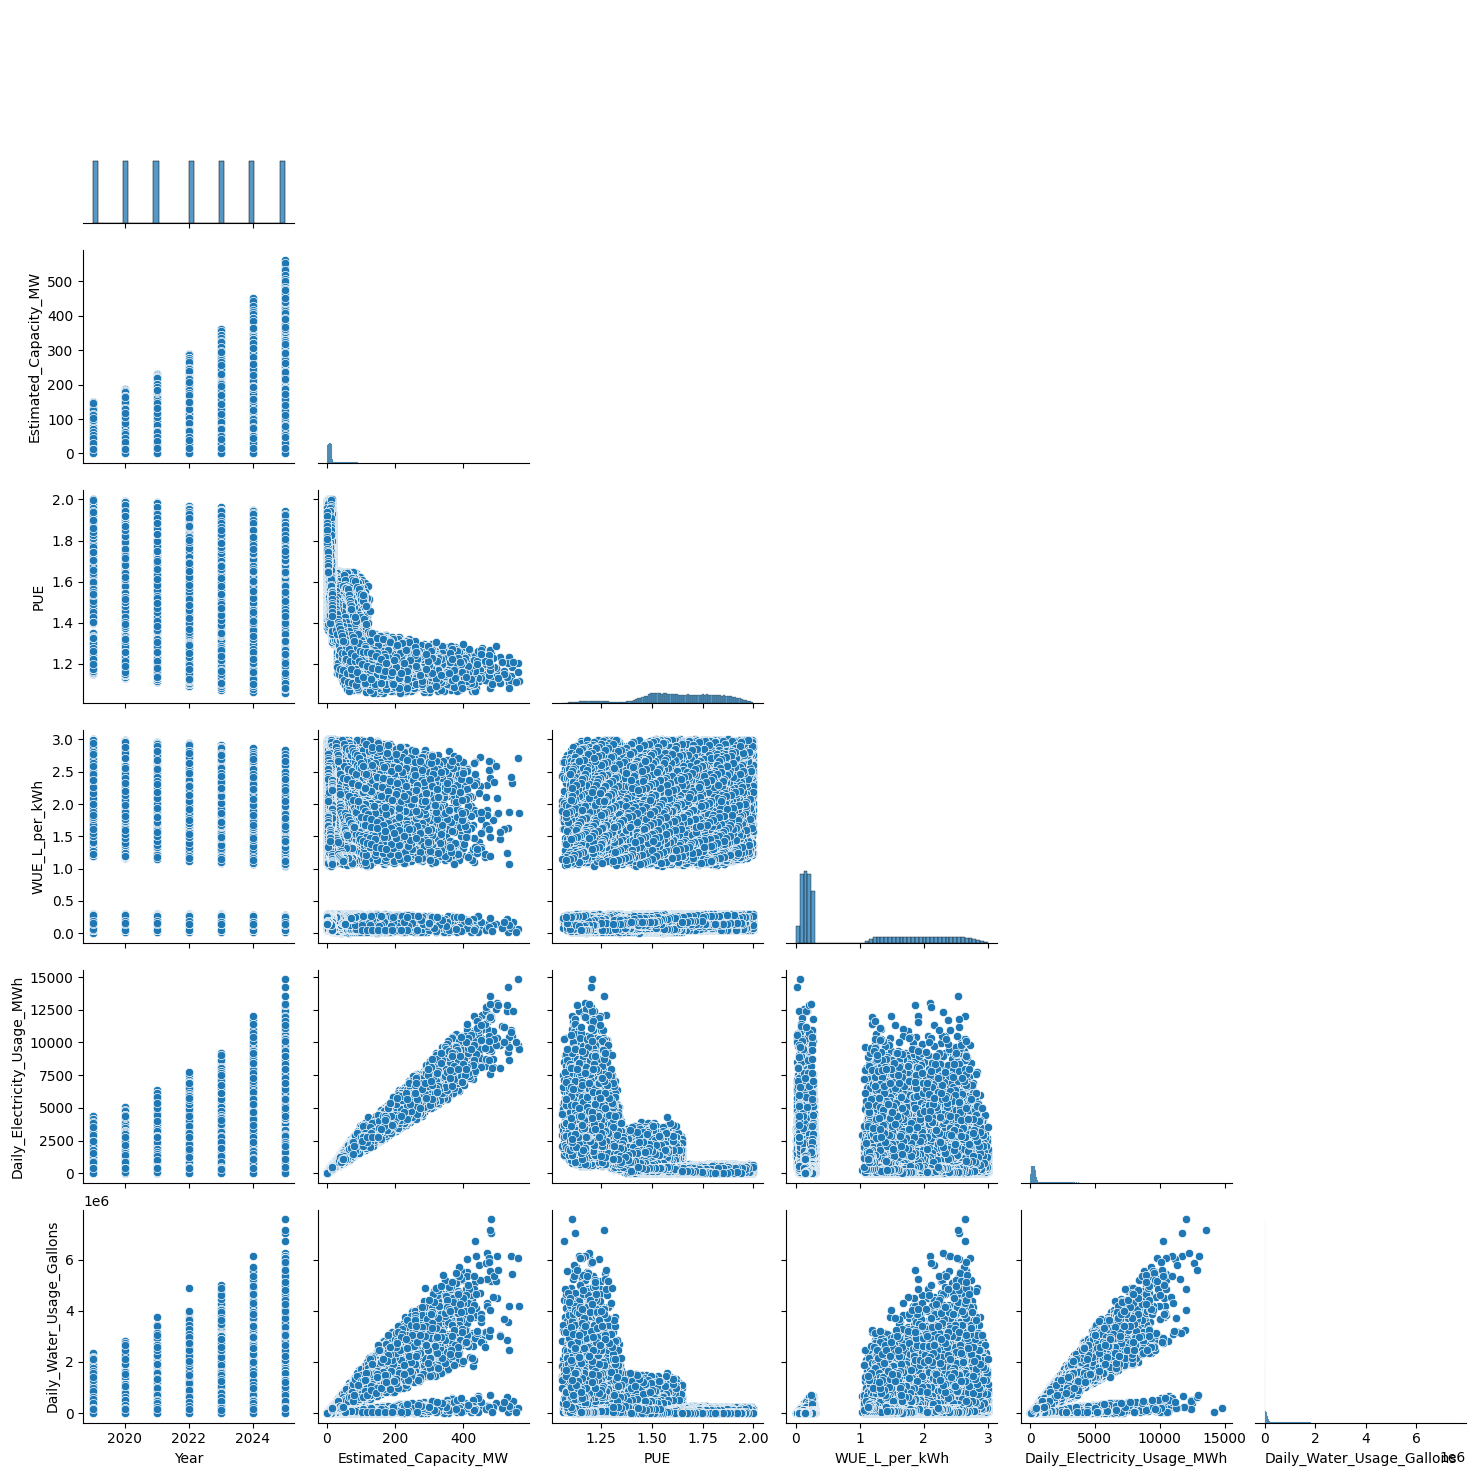

In [10]:
# Plotting only useful columns
grid = sns.pairplot(df,corner=True)

In [16]:
# For saving the plot
'''

grid.savefig('DataCenterpairplot.png', dpi=300, bbox_inches='tight')


'''
print('This plot gives us a rough idea of the data')

This plot gives us a rough idea of the data


In [26]:
le = LabelEncoder()
df['Surrounding_Water_Stress_Tier'] = le.fit_transform(df['Surrounding_Water_Stress_Tier'])

<Axes: >

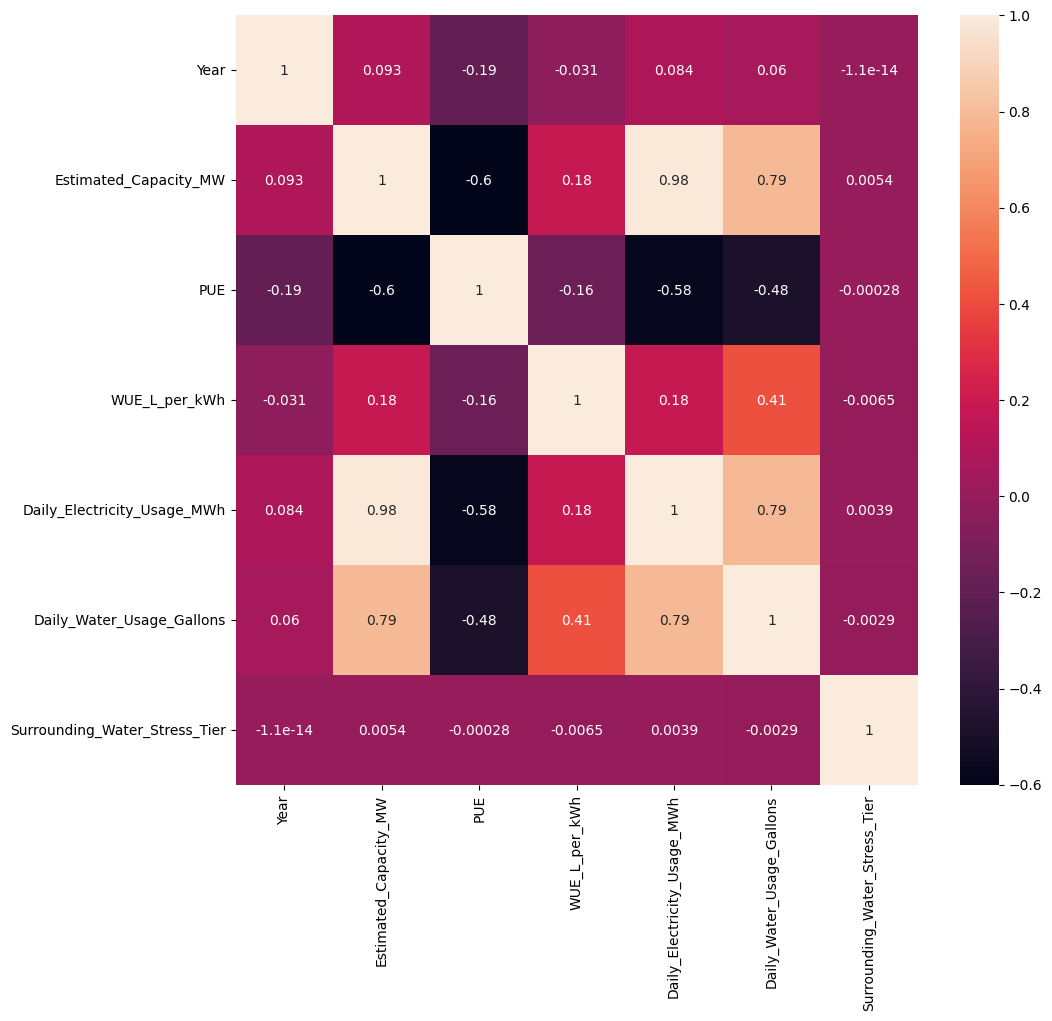

In [27]:
plt.figure(figsize=(11,10))
sns.heatmap(df.corr(numeric_only=True),annot=True)

In [20]:
for col in df.select_dtypes(include=['object', 'category']):
    print(df[col].value_counts())
    print("-" * 20)  # Separator line


Facility_ID
DC-D2763E00    7
DC-21C0EA0D    7
DC-518B7F4C    7
DC-6D0E9079    7
DC-B0E5037A    7
              ..
DC-1C259F9E    7
DC-3CAF05F5    7
DC-232F02F1    7
DC-B2E3F8DD    7
DC-31D8B15E    7
Name: count, Length: 18110, dtype: int64
--------------------
Facility_Name
Amsterdam                     231
Singapore                     217
London                        189
Sydney                        161
Frankfurt                     154
                             ... 
Northland Utica Datacenter      7
SS&C GlobeOp Data Center        7
Hivelocity - Seattle 1          7
2020 5th Avenue (SEA11)         7
ICS_DataCenter_216              7
Name: count, Length: 16286, dtype: int64
--------------------
Owner_Company
Amazon AWS                                               3731
Equinix                                                  3374
Lumen                                                    2821
China Telecom                                            2212
Zenlayer                   

In [19]:


df.select_dtypes(include='number').columns.tolist()


['Year',
 'Estimated_Capacity_MW',
 'PUE',
 'WUE_L_per_kWh',
 'Daily_Electricity_Usage_MWh',
 'Daily_Water_Usage_Gallons']

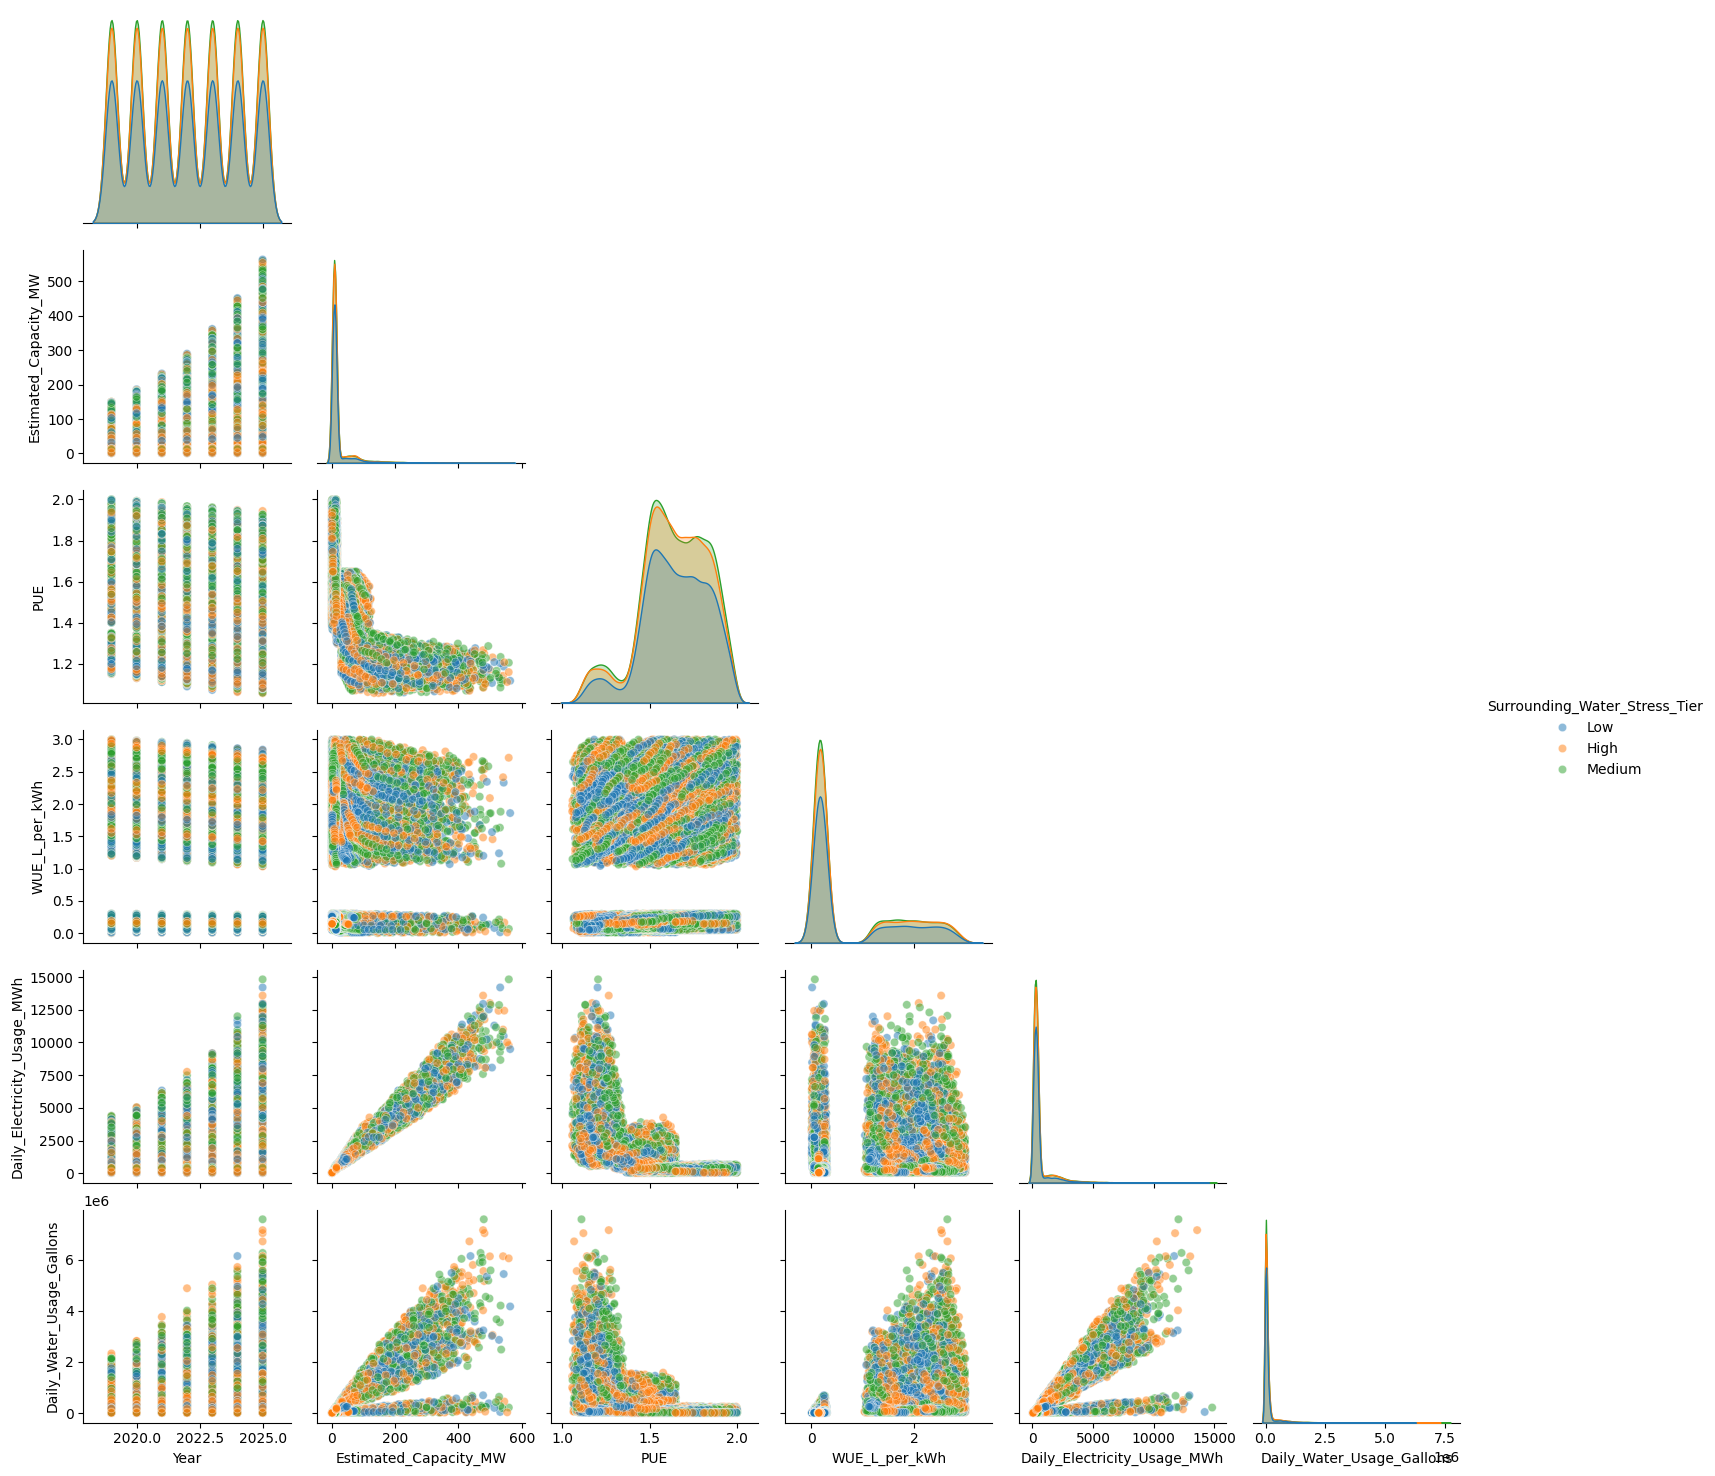

In [21]:
churnplot = sns.pairplot(
            df,
            vars=['Year','Estimated_Capacity_MW','PUE','WUE_L_per_kWh',
                  'Daily_Electricity_Usage_MWh','Daily_Water_Usage_Gallons'],
            hue='Surrounding_Water_Stress_Tier',
            plot_kws={'alpha':0.5},
            corner = True
            )

In [22]:
'''

churnplot.savefig('WaterStresschurn.png', dpi=300, bbox_inches='tight')

'''

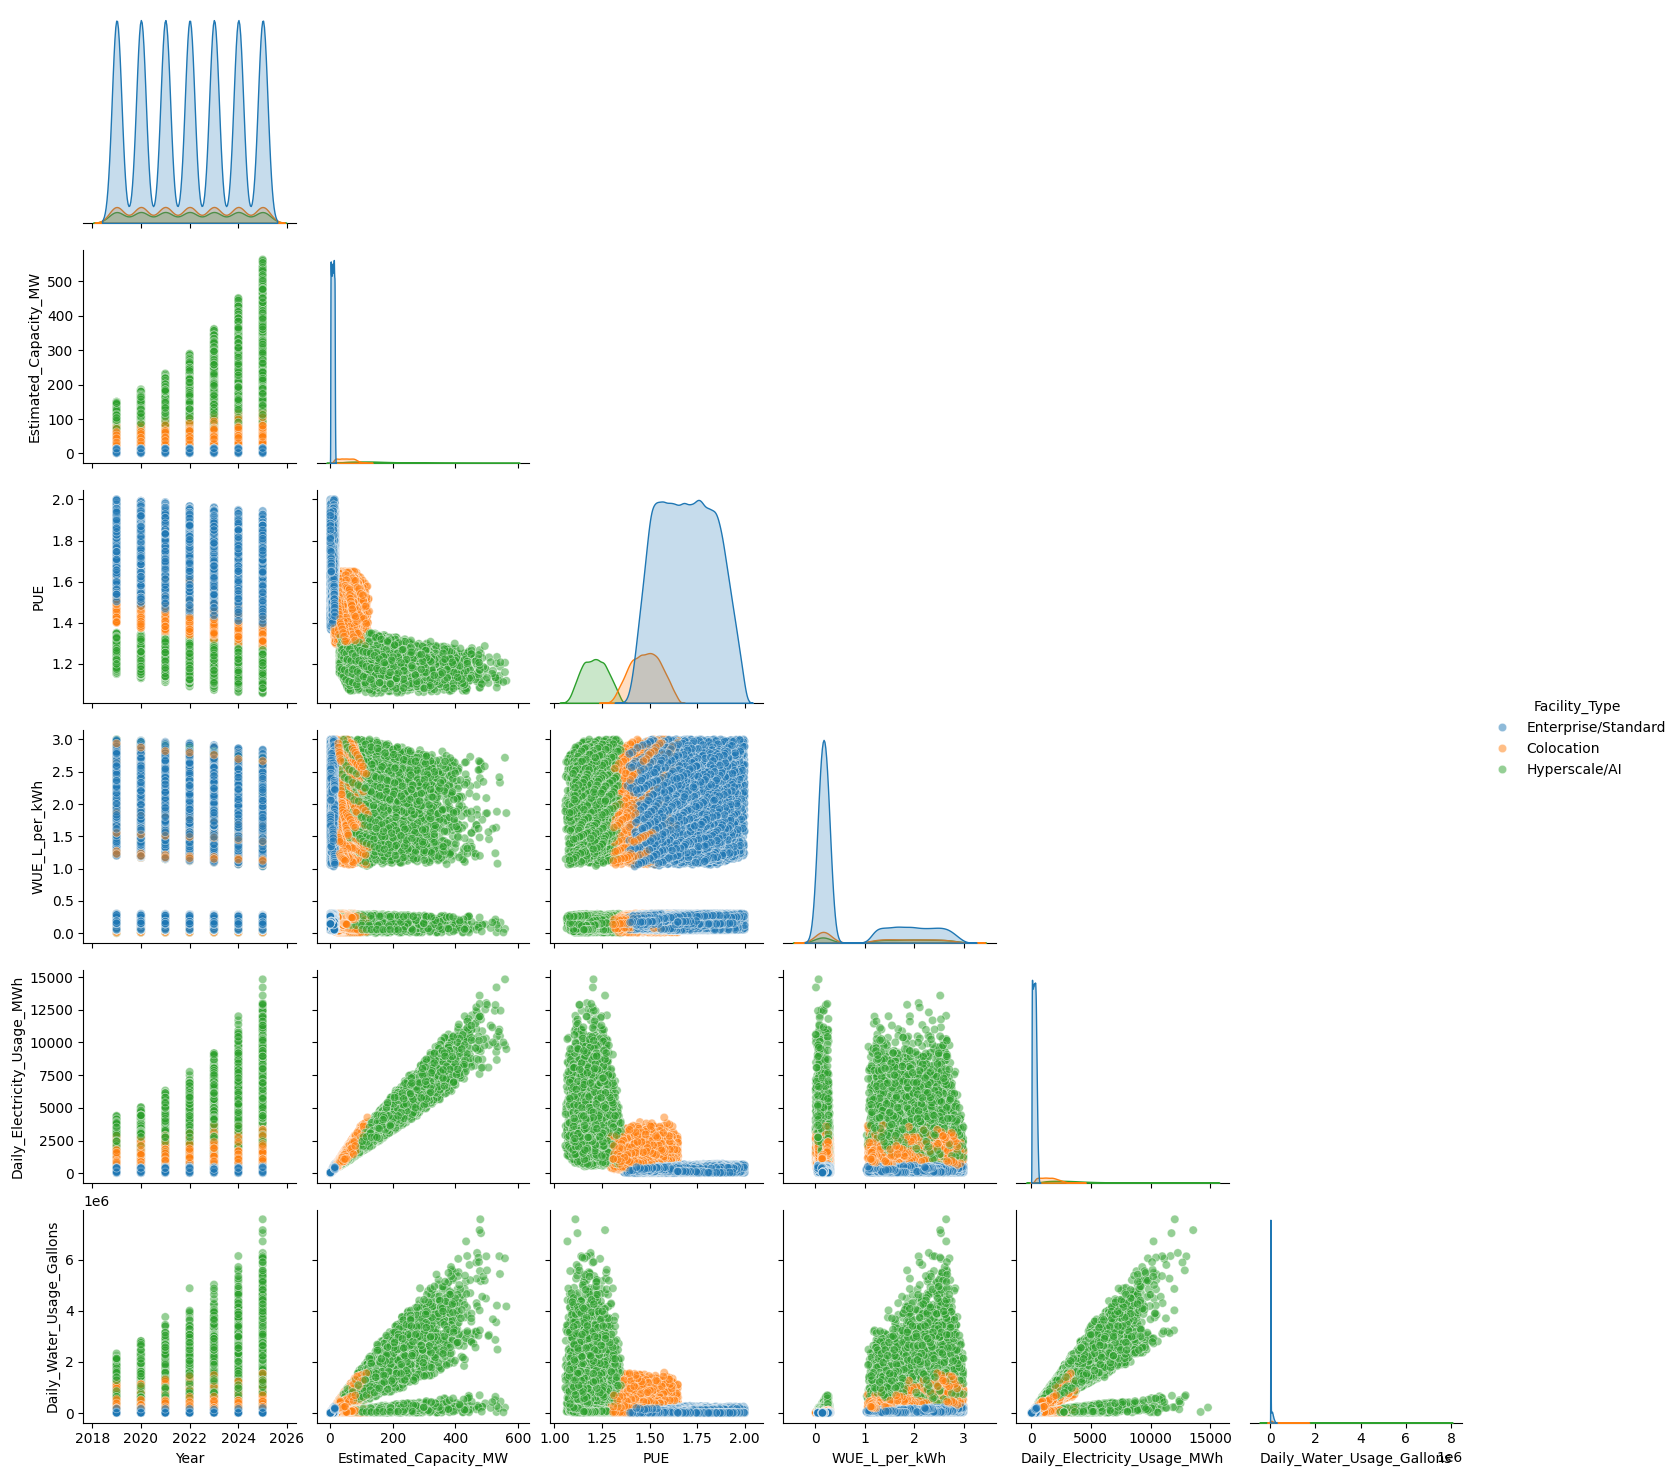

In [23]:
churnplot = sns.pairplot(
            df,
            vars=['Year','Estimated_Capacity_MW','PUE','WUE_L_per_kWh',
                  'Daily_Electricity_Usage_MWh','Daily_Water_Usage_Gallons'],
            hue='Facility_Type',
            plot_kws={'alpha':0.5},
            corner = True
            )

In [24]:
'''

churnplot.savefig('FacilityTypechurn.png', dpi=300, bbox_inches='tight')

'''